## Import Libaries

In [2]:
import pandas as pd
import numpy as np


## Load The DataSet

In [3]:
df = pd.read_csv("D:\joel\Project\Supply_Chain_Project\Data\DataCoSupplyChainDataset.csv", encoding='latin1')

#print(df)

<>:1: SyntaxWarning: invalid escape sequence '\j'
<>:1: SyntaxWarning: invalid escape sequence '\j'
C:\Users\Joel\AppData\Local\Temp\ipykernel_20884\4062147435.py:1: SyntaxWarning: invalid escape sequence '\j'
  df = pd.read_csv("D:\joel\Project\Supply_Chain_Project\Data\DataCoSupplyChainDataset.csv", encoding='latin1')


## View The Data

In [4]:
print(df.head(5))

       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                   0           73  Sporting Goods        Caguas  ...   
1                   1           73  Sporting Goo

In [5]:
## Check Data set type

print(df.shape)

(180519, 53)


In [6]:
## Check column names

print(df.columns)

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [7]:
# Check data types

print(df.dtypes)

Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market          

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

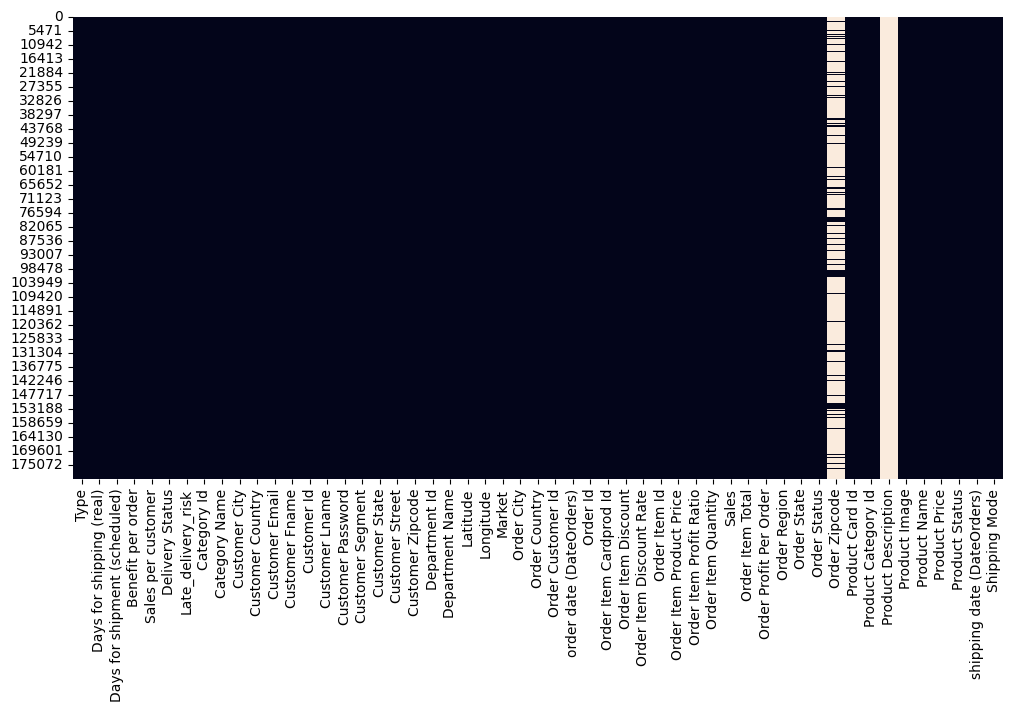

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False)

plt.show()

In [10]:
# Check duplicates

print(df.duplicated().sum())

0


In [11]:
# Remove Duplicates

df.drop_duplicates(inplace=True)

## Handle Missing Values

In [12]:
# Check which column have Nulls

missing_values = df.isnull().sum()

print(
    missing_values[missing_values >0]
)

Customer Lname              8
Customer Zipcode            3
Order Zipcode          155679
Product Description    180519
dtype: int64


In [13]:
# Filling Null Values For customer Lname, customer zipcode , order zipcode

columns_fill = {
    'Customer Lname' : 'Unknown',
    'Order Zipcode' : 'Unknown'
}

for col, value in columns_fill.items():
    if col in df.columns:
        df[col] = df[col].fillna(value)

        print(f"Null values filled in '{col}' with '{value}'")


# special handling for customer zipcode using mode 

if 'Customer Zipcode' in df.columns:
    df['Customer Zipcode'] = df['Customer Zipcode'].fillna(
        df['Customer Zipcode'].mode()[0]
    )

    print("Null values filled in 'Customer Zipcode' using Mode Value")

print("\nRemaining Null Values :")
print(df.isnull().sum()) 

Null values filled in 'Customer Lname' with 'Unknown'
Null values filled in 'Order Zipcode' with 'Unknown'
Null values filled in 'Customer Zipcode' using Mode Value

Remaining Null Values :
Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        0
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      0
Department

## Remove highly useless Null Columns

In [14]:
columns_to_drop = [
    'Product Description',
    'Product Image'
]

for col in columns_to_drop:

    print(f"Checking column: {col}")

    if col in df.columns:

        df.drop(columns=col, inplace=True)

        print(f"✅ Dropped: {col}")

    else:

        print(f"❌ Not Found: {col}")

print("\nFinal Shape:")
print(df.shape)

Checking column: Product Description
✅ Dropped: Product Description
Checking column: Product Image
✅ Dropped: Product Image

Final Shape:
(180519, 51)


## Convert Date Columns

In [15]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product Na

In [16]:
date_columns = [
    'order date (DateOrders)',
    'shipping date (DateOrders)'
]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

        print(f"✅ '{col}' converted to datetime")

    else:

        print(f"❌ '{col}' not found")

✅ 'order date (DateOrders)' converted to datetime
✅ 'shipping date (DateOrders)' converted to datetime


In [17]:
print(df[['order date (DateOrders)', 
          'shipping date (DateOrders)']].dtypes)

order date (DateOrders)       datetime64[ns]
shipping date (DateOrders)    datetime64[ns]
dtype: object


# Create new Business Columns 
## Feature Engineering 

### Delivery delay

In [18]:
df['Delivery Delay'] = (
    df['Days for shipping (real)'] 
    -
    df['Days for shipment (scheduled)']
)

In [19]:
print(df['Delivery Delay'])

0        -1
1         1
2         0
3        -1
4        -2
         ..
180514    0
180515    1
180516    1
180517   -1
180518    0
Name: Delivery Delay, Length: 180519, dtype: int64


### Profit Margin %

In [20]:
df['Profit Margin %'] = np.where(

    df['Sales per customer'] !=0,

    (
       df['Benefit per order']
       /
       df['Sales per customer'] 
    ) * 100,

    0
)


In [21]:
df['Profit Margin %'] = df['Profit Margin %'].round(2)
print(df['Profit Margin %'])

0          29.0
1         -80.0
2         -80.0
3           7.5
4          45.0
          ...  
180514     10.0
180515   -155.0
180516     36.0
180517     48.0
180518     44.0
Name: Profit Margin %, Length: 180519, dtype: float64


### LOSS FLAG

In [22]:
df['Loss flag'] = np.where(
    df['Benefit per order'] <0,
    'Loss',
    'Profit'
)


In [23]:
print(df['Loss flag'])

0         Profit
1           Loss
2           Loss
3         Profit
4         Profit
           ...  
180514    Profit
180515      Loss
180516    Profit
180517    Profit
180518    Profit
Name: Loss flag, Length: 180519, dtype: object


### Shipping Efficiency

In [24]:
if 'Delivery Delay' in df.columns:

    df['Shipping Efficiency'] = np.where(
        df['Delivery Delay'] <= 0,
        'Efficient',
        'Delayed'
    )

    print("'Shipping Efficient' column created successfully")

else:

    print("'Delivery Delay' column not found")



'Shipping Efficient' column created successfully


In [25]:
print(df['Shipping Efficiency'].head(10))

0    Efficient
1      Delayed
2    Efficient
3    Efficient
4    Efficient
5      Delayed
6      Delayed
7      Delayed
8      Delayed
9      Delayed
Name: Shipping Efficiency, dtype: object


### Order value category

In [26]:
df['Sales per customer'].describe()

count    180519.000000
mean        183.107609
std         120.043670
min           7.490000
25%         104.379997
50%         163.990005
75%         247.399994
max        1939.989990
Name: Sales per customer, dtype: float64

In [27]:
if 'Sales per customer' in df.columns:
    df['Order Value Category'] = pd.cut(

        df['Sales per customer'],

        bins=[0, 100, 250, 500, 2000],

        labels=[
            'Low Value',
            'Medium Value',
            'High Value',
            'Premium Value'
        ]
    )

    print("'Order Value Category' column created sucessfully")

else:

    print("'Sales per customer' column not found")

'Order Value Category' column created sucessfully


In [28]:
print(df['Order Value Category'].head(10))

0    High Value
1    High Value
2    High Value
3    High Value
4    High Value
5    High Value
6    High Value
7    High Value
8    High Value
9    High Value
Name: Order Value Category, dtype: category
Categories (4, object): ['Low Value' < 'Medium Value' < 'High Value' < 'Premium Value']


In [29]:
print(df['Order Value Category'].value_counts())

Order Value Category
Medium Value     94812
Low Value        42596
High Value       42440
Premium Value      671
Name: count, dtype: int64


### Discount Category

In [30]:
df['Order Item Discount'].describe()

count    180519.000000
mean         20.664741
std          21.800901
min           0.000000
25%           5.400000
50%          14.000000
75%          29.990000
max         500.000000
Name: Order Item Discount, dtype: float64

In [31]:
if 'Order Item Discount' in df.columns:

    df['Discount Category'] = pd.cut(

        df['Order Item Discount'],

        bins=[-1, 0, 50, 100, 500],

        labels=[
            'No Discount',
            'Low Discount',
            'Medium Discount',
            'High Discount'
        ]
    )

    print("'Discount Category' column created successfully")

else:

    print("'Order Item Discount' column not found")
    

'Discount Category' column created successfully


In [32]:
print(df['Discount Category'].head(10))

0       Low Discount
1       Low Discount
2       Low Discount
3       Low Discount
4       Low Discount
5       Low Discount
6       Low Discount
7       Low Discount
8       Low Discount
9    Medium Discount
Name: Discount Category, dtype: category
Categories (4, object): ['No Discount' < 'Low Discount' < 'Medium Discount' < 'High Discount']


In [33]:
print(df['Discount Category'].value_counts())

Discount Category
Low Discount       154289
Medium Discount     15655
No Discount         10028
High Discount         547
Name: count, dtype: int64


### High Profit Order

In [34]:
df['Benefit per order'].describe()

count    180519.000000
mean         21.974989
std         104.433526
min       -4274.979980
25%           7.000000
50%          31.520000
75%          64.800003
max         911.799988
Name: Benefit per order, dtype: float64

In [35]:
df['Profit Category'] = pd.cut(

    df['Benefit per order'],

    bins=[-5000, 0, 30, 65, 1000],

    labels=[
        'Loss',
        'Low Profit',
        'Medium Profit',
        'High Profit'
    ]
)

print("'Profit Category' column created successfully")

'Profit Category' column created successfully


In [36]:
print(df['Profit Category'].head(10))

0    High Profit
1           Loss
2           Loss
3     Low Profit
4    High Profit
5     Low Profit
6    High Profit
7    High Profit
8    High Profit
9    High Profit
Name: Profit Category, dtype: category
Categories (4, object): ['Loss' < 'Low Profit' < 'Medium Profit' < 'High Profit']


In [37]:
print(df['Profit Category'].value_counts())

Profit Category
Low Profit       53111
Medium Profit    47504
High Profit      44943
Loss             34961
Name: count, dtype: int64


### Delivery Performance

In [38]:
df['Delivery Delay'].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Delivery Delay, dtype: float64

In [39]:
if 'Delivery Delay' in df.columns:

    df['Delivery Performance'] = pd.cut(

        df['Delivery Delay'],

        bins=[-3, 0, 1, 2, 5],

        labels=[
            'Early Delivery',
            'On Time',
            'Slight Delay',
            'Highly Delayed'
        ]
    )

    print("'Delivery Performance' column created successfully")

else:

    print("'Delivery Delay' column not found")

'Delivery Performance' column created successfully


In [40]:
print(df['Delivery Performance'].head(10))

0    Early Delivery
1           On Time
2    Early Delivery
3    Early Delivery
4    Early Delivery
5      Slight Delay
6           On Time
7           On Time
8           On Time
9           On Time
Name: Delivery Performance, dtype: category
Categories (4, object): ['Early Delivery' < 'On Time' < 'Slight Delay' < 'Highly Delayed']


In [41]:
print(df['Delivery Performance'].value_counts())

Delivery Performance
Early Delivery    77119
On Time           60647
Slight Delay      28718
Highly Delayed    14035
Name: count, dtype: int64


In [42]:
print(

    df[[

        'Delivery Delay',

        'Profit Margin %',

        'Loss flag',

        'Shipping Efficiency',

        'Order Value Category'

    ]].head(5)

)

   Delivery Delay  Profit Margin % Loss flag Shipping Efficiency  \
0              -1             29.0    Profit           Efficient   
1               1            -80.0      Loss             Delayed   
2               0            -80.0      Loss           Efficient   
3              -1              7.5    Profit           Efficient   
4              -2             45.0    Profit           Efficient   

  Order Value Category  
0           High Value  
1           High Value  
2           High Value  
3           High Value  
4           High Value  


In [43]:
# check null 
print(df.isnull().sum())

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Email                   0
Customer Fname                   0
Customer Id                      0
Customer Lname                   0
Customer Password                0
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 0
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
order date (DateOrde

In [44]:
# Replace positive and negative infinity values

df.replace(

    [np.inf, -np.inf],

    0,

    inplace=True
)

print("Infinity values replaced successfully")

Infinity values replaced successfully


In [45]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 59 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  object        
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Id                    180519 non-null  int64         
 8   Category Name                  180519 non-null  object        
 9   Customer City                  180519 non-null  object        
 10  Customer Country               180519 non-null  object        
 11  

In [46]:
print(df.shape)

(180519, 59)


### Save Cleaned Data

In [47]:
df.to_csv(
    "D:\joel\Project\Supply_Chain_Project\Output\cleaned_supply_chain.csv",

    index=False
)

<>:2: SyntaxWarning: invalid escape sequence '\j'
<>:2: SyntaxWarning: invalid escape sequence '\j'
C:\Users\Joel\AppData\Local\Temp\ipykernel_20884\2295552290.py:2: SyntaxWarning: invalid escape sequence '\j'
  "D:\joel\Project\Supply_Chain_Project\Output\cleaned_supply_chain.csv",


In [48]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product Na

In [49]:
(df['Sales'] == df['Sales per customer']).sum()

10028

In [50]:
len(df)

180519

In [51]:
df[['Sales', 'Sales per customer']].head(10)

,Sales,Sales per customer
0,327.75,314.640015
1,327.75,311.359985
2,327.75,309.720001
3,327.75,304.809998
4,327.75,298.250000
5,327.75,294.980011
6,327.75,288.420013
7,327.75,285.140015
8,327.75,278.589996
9,327.75,275.309998


In [ ]:
df[['Benefit per order', 'Order Profit Per Order']].head(10)

,Benefit per order,Order Profit Per Order
0,91.250000,91.250000
1,-249.089996,-249.089996
2,-247.779999,-247.779999
3,22.860001,22.860001
4,134.210007,134.210007
5,18.580000,18.580000
6,95.180000,95.180000
7,68.430000,68.430000
8,133.720001,133.720001
9,132.149994,132.149994


In [53]:
(df['Benefit per order'] == df['Order Profit Per Order']).sum()

180519

In [54]:
df['Product Status'].value_counts()

Product Status
0    180519
Name: count, dtype: int64